In [1]:
import json as _json
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
)

import joblib
import shap

RANDOM_STATE = 42


In [2]:
raw = pd.read_csv("../data/raw/diabetic_data.csv")
raw = raw.replace("?", np.nan)
raw = raw[raw["gender"] != "Unknown/Invalid"].copy()
raw["readmitted_30"] = (raw["readmitted"] == "<30").astype(int)

X_raw = raw.drop(columns=["readmitted_30"])
y_raw = raw["readmitted_30"]
groups_raw = raw["patient_nbr"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(X_raw, y_raw, groups=groups_raw))
patient_nbr_train = raw.iloc[train_idx]["patient_nbr"].reset_index(drop=True)

TARGET = "readmitted_30"
train_df = pd.read_csv("../data/processed/train_clean_selected.csv")
test_df = pd.read_csv("../data/processed/test_clean_selected.csv")

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

lr_model = joblib.load("../models/logistic_regression_tuned.joblib")
rf_model = joblib.load("../models/random_forest_tuned.joblib")
xgb_model = joblib.load("../models/xgboost_tuned.joblib")
ensemble_model = joblib.load("../models/final_ensemble.joblib")

with open("../results/xgboost_tuned_summary.json") as f:
    xgb_summary = _json.load(f)
with open("../results/lr_rf_tuned_summary.json") as f:
    lr_rf_summary = _json.load(f)
with open("../results/ensemble_summary.json") as f:
    ensemble_summary = _json.load(f)

lr_summary = lr_rf_summary["logistic_regression"]
rf_summary = lr_rf_summary["random_forest"]

models = {
    "Logistic Regression": (lr_model, lr_summary.get("chosen_threshold", 0.5)),
    "Random Forest": (rf_model, rf_summary.get("chosen_threshold", 0.5)),
    "XGBoost": (xgb_model, xgb_summary.get("chosen_threshold", 0.5)),
    "Ensemble (LR+RF+XGB, Soft Voting)": (ensemble_model, ensemble_summary.get("chosen_threshold", 0.5)),
}

print("Loaded all four final models and their saved thresholds.")


Loaded all four final models and their saved thresholds.


In [3]:
perf_rows = []
for name, (model, threshold) in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    perf_rows.append({
        "Model": name,
        "Test PR-AUC": average_precision_score(y_test, proba),
        "Test ROC-AUC": roc_auc_score(y_test, proba),
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })

perf_df = pd.DataFrame(perf_rows).sort_values("Test PR-AUC", ascending=False)
print(perf_df.to_string(index=False))


                            Model  Test PR-AUC  Test ROC-AUC  Threshold  Precision   Recall       F1
Ensemble (LR+RF+XGB, Soft Voting)     0.195269      0.630413   0.455468   0.134651 0.734247 0.227569
                    Random Forest     0.194896      0.631024   0.448491   0.134320 0.733790 0.227074
                          XGBoost     0.193615      0.629698   0.432132   0.119007 0.914612 0.210609
              Logistic Regression     0.191502      0.626624   0.435122   0.128833 0.790411 0.221554


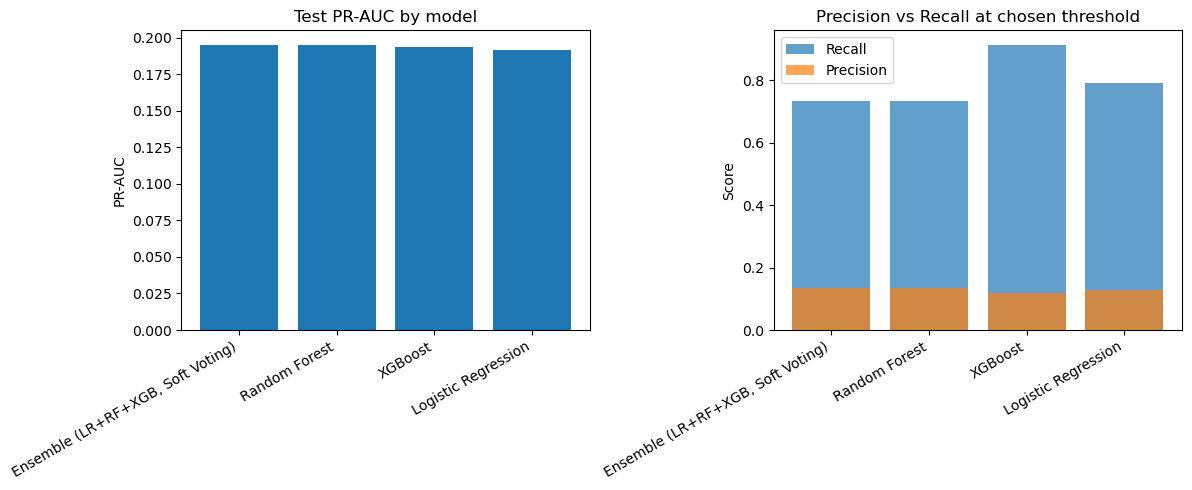

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(perf_df))
axes[0].bar(x, perf_df["Test PR-AUC"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(perf_df["Model"], rotation=30, ha="right")
axes[0].set_ylabel("PR-AUC")
axes[0].set_title("Test PR-AUC by model")

axes[1].bar(x, perf_df["Recall"], label="Recall", alpha=0.7)
axes[1].bar(x, perf_df["Precision"], label="Precision", alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(perf_df["Model"], rotation=30, ha="right")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision vs Recall at chosen threshold")
axes[1].legend()

plt.tight_layout()
plt.show()


In [5]:
efficiency_rows = []

base_estimators_for_timing = {
    "Logistic Regression": clone(lr_model),
    "Random Forest": clone(rf_model),
    "XGBoost": clone(xgb_model),
}

fitted_for_timing = {}
for name, est in base_estimators_for_timing.items():
    start = time.perf_counter()
    est.fit(X_train, y_train)
    fit_time = time.perf_counter() - start
    fitted_for_timing[name] = est

    start = time.perf_counter()
    _ = est.predict_proba(X_test)
    predict_time = time.perf_counter() - start
    per_1000 = predict_time / len(X_test) * 1000

    efficiency_rows.append({
        "Model": name,
        "Fit time (s)": fit_time,
        "Inference time (s, full test set)": predict_time,
        "Inference time (s per 1000 rows)": per_1000,
    })

# Ensemble timing: fit time is the sum of its three base estimators (soft voting requires all three
# fitted); inference time is the sum of three predict_proba calls plus a negligible averaging step.
ensemble_fit_time = sum(r["Fit time (s)"] for r in efficiency_rows)
ensemble_predict_time = sum(r["Inference time (s, full test set)"] for r in efficiency_rows)
efficiency_rows.append({
    "Model": "Ensemble (LR+RF+XGB)",
    "Fit time (s)": ensemble_fit_time,
    "Inference time (s, full test set)": ensemble_predict_time,
    "Inference time (s per 1000 rows)": ensemble_predict_time / len(X_test) * 1000,
})

efficiency_df = pd.DataFrame(efficiency_rows)
print(efficiency_df.to_string(index=False))


C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


               Model  Fit time (s)  Inference time (s, full test set)  Inference time (s per 1000 rows)
 Logistic Regression      4.224878                           0.003034                          0.000150
       Random Forest      4.250372                           0.108072                          0.005340
             XGBoost      0.168144                           0.005716                          0.000282
Ensemble (LR+RF+XGB)      8.643394                           0.116823                          0.005773


In [6]:
overfitting_rows = []
for name, est in fitted_for_timing.items():
    train_proba = est.predict_proba(X_train)[:, 1]
    test_proba_i = est.predict_proba(X_test)[:, 1]
    train_prauc = average_precision_score(y_train, train_proba)
    test_prauc = average_precision_score(y_test, test_proba_i)
    overfitting_rows.append({
        "Model": name,
        "Train PR-AUC": train_prauc,
        "Test PR-AUC": test_prauc,
        "Gap (train - test)": train_prauc - test_prauc,
    })

overfitting_df = pd.DataFrame(overfitting_rows).sort_values("Gap (train - test)", ascending=False)
print(overfitting_df.to_string(index=False))


              Model  Train PR-AUC  Test PR-AUC  Gap (train - test)
            XGBoost      0.206559     0.193615            0.012944
      Random Forest      0.206730     0.194896            0.011833
Logistic Regression      0.192770     0.191502            0.001267


In [7]:
# Logistic Regression: absolute coefficient magnitude (L1-penalised, so many will be exactly zero)
lr_coefs = pd.Series(np.abs(lr_model.coef_[0]), index=X_train.columns).sort_values(ascending=False)

# Random Forest: native feature_importances_
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# XGBoost: mean absolute SHAP value (reusing D022's method, computed fresh here for this table)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
xgb_shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train.columns).sort_values(ascending=False)

interpretability_comparison = pd.DataFrame({
    "LR (|coef|) rank": lr_coefs.rank(ascending=False).astype(int),
    "RF (importance) rank": rf_importances.rank(ascending=False).astype(int),
    "XGB (|SHAP|) rank": xgb_shap_importance.rank(ascending=False).astype(int),
})

# Show the features that rank in the top 10 for at least one model
top_features = set(lr_coefs.head(10).index) | set(rf_importances.head(10).index) | set(xgb_shap_importance.head(10).index)
print(interpretability_comparison.loc[list(top_features)].sort_values("XGB (|SHAP|) rank"))


                                   LR (|coef|) rank  RF (importance) rank  \
num__number_inpatient                             1                     1   
ord__age                                          4                     3   
nom__diag_1_group_Respiratory                     2                     4   
num__number_emergency                             6                     2   
nom__diag_1_group_Circulatory                    10                     7   
nom__medical_specialty_Cardiology                 3                     6   
num__number_outpatient                           15                     5   
nom__admission_source_id_7                       13                    13   
nom__diag_1_group_Diabetes                        7                     8   
nom__diag_1_group_Digestive                       5                    15   
nom__A1Cresult_Missing                           11                     9   
nom__medical_specialty_Missing                    8                    10   

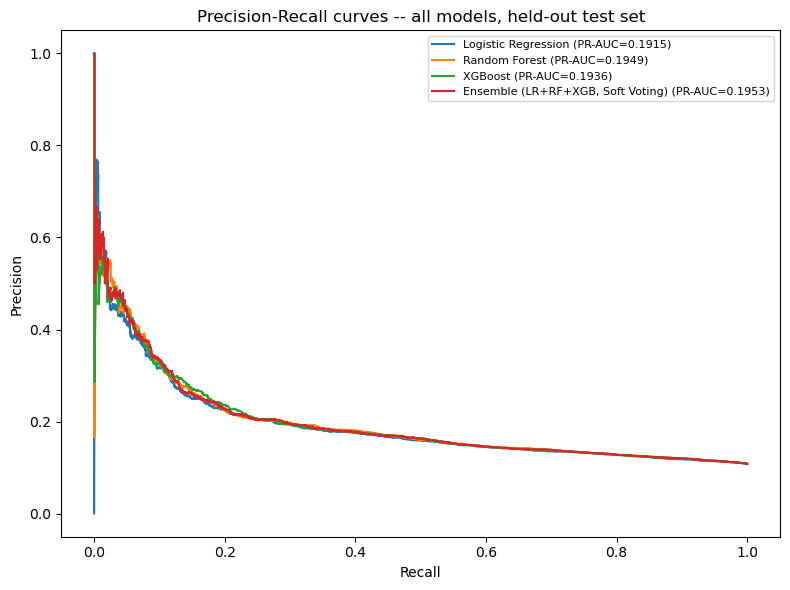

In [8]:
plt.figure(figsize=(8, 6))
for name, (model, threshold) in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, _ = precision_recall_curve(y_test, proba)
    plt.plot(recalls, precisions, label=f"{name} (PR-AUC={average_precision_score(y_test, proba):.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves -- all models, held-out test set")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


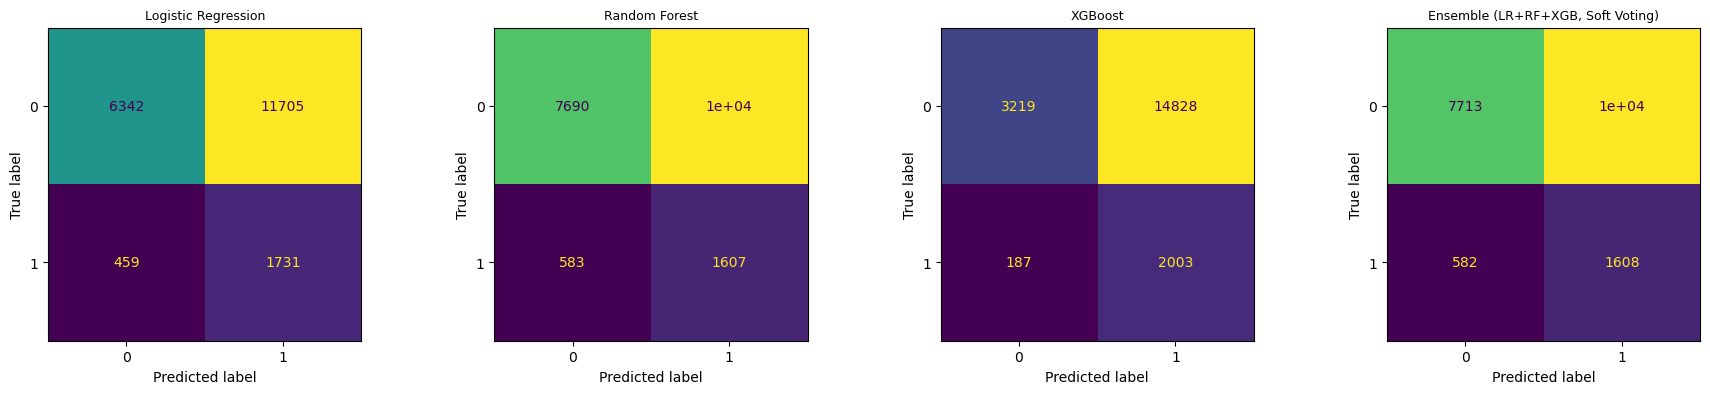

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, (model, threshold)) in zip(axes, models.items()):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred)).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show()


In [10]:
os.makedirs("../results", exist_ok=True)

part_h_summary = {
    "predictive_performance": perf_df.to_dict("records"),
    "computational_efficiency": efficiency_df.to_dict("records"),
    "overfitting_check": overfitting_df.to_dict("records"),
    "interpretability_top_features": {
        "logistic_regression_top10": lr_coefs.head(10).to_dict(),
        "random_forest_top10": rf_importances.head(10).to_dict(),
        "xgboost_shap_top10": xgb_shap_importance.head(10).to_dict(),
    },
}

with open("../results/part_h_summary.json", "w") as f:
    _json.dump(part_h_summary, f, indent=2, default=str)

print("Saved ../results/part_h_summary.json")

Saved ../results/part_h_summary.json
